In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Datos de entrenamiento

In [ ]:
# Datos de 10 personas → [edad, ahorro]
# edad: 1 → 100 años
# ahorros: 1 → $100,000
personas = np.array([
    [0.3, 0.4], [0.4, 0.3],
    [0.3, 0.2], [0.4, 0.1],
    [0.5, 0.2], [0.4, 0.8],
    [0.6, 0.8], [0.5, 0.6],
    [0.7, 0.6], [0.8, 0.5]
])

#1: aprobada
#0: denegada
clases = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

### Gráfica de dispersión

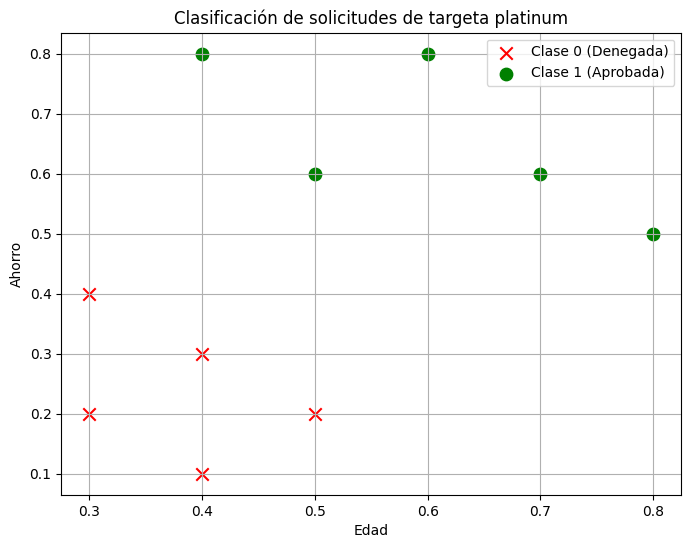

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(personas[clases == 0, 0], personas[clases == 0, 1], c='red', marker='x', label='Clase 0 (Denegada)', s=80)
plt.scatter(personas[clases == 1, 0], personas[clases == 1, 1], c='green', marker='o', label='Clase 1 (Aprobada)', s=80)
plt.xlabel('Edad')
plt.ylabel('Ahorro')
plt.title('Clasificación de solicitudes de targeta platinum')
plt.legend()
plt.grid(True)
plt.show()

Función de activación escalon

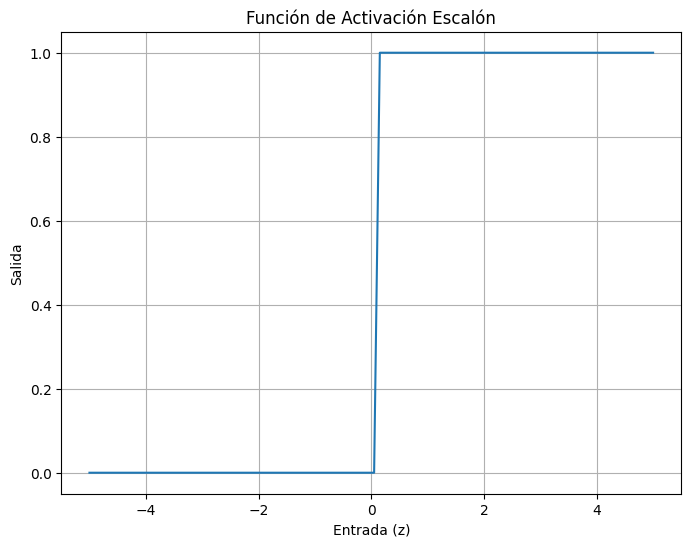

In [ ]:
def escalon(pesos, b, x):
  z = pesos * x
  if z.sum() + b > 0:
    return 1
  else:
    return 0

pesos = np.random.uniform(-1, 1, size=2)
b = np.random.uniform(-1, 1)

# Generar valores para el eje x
x_values = np.linspace(-5, 5, 100)

# Aplicar la función escalón a los valores de x
y_values = [escalon(pesos, b, x) for x in x_values]

# Graficar la función escalón
plt.figure(figsize=(8, 6))
plt.plot(x_values, y_values)
plt.title('Función de Activación Escalón')
plt.xlabel('Entrada (z)')
plt.ylabel('Salida')
plt.grid(True)
plt.show()

## Función de activación

In [ ]:
# Definición de la función de activación
def activacion (pesos, x, b):
  # Calcula la suma ponderada de las entradas y el sesgo
  z = np.dot(pesos, x) + b
  # Aplica la función escalón: retorna 1 si la suma es positiva, 0 en caso contrario
  if z > 0:
    return 1
  else:
    return 0

In [ ]:
#Pruebas con nuevos clientes
nClientes = np.array([[0.3, 0.5], [0.2, 0.8]])
pesos = np.random.uniform(-1, 1, size=2)
b = np.random.uniform(-1, 1)
print("Pruebas con nuevos clientes:")
for cliente in nClientes:
    resultado_prediccion = activacion(pesos, cliente, b)
    print(f"Cliente: {cliente}, Predicción: {resultado_prediccion}")

Pruebas con nuevos clientes:
Cliente: [0.3 0.5], Predicción: 0
Cliente: [0.2 0.8], Predicción: 0


## Entrenamiento perceptrón simple

In [ ]:
# Función de entrenamiento
def entrenamiento (tasaAprendizaje, epochs, weights, bias):
  # Ciclo de entrenamiento
  print("Entrenamiento del perceptrón...")
  for epoc in range(epochs):
    errorTotal = 0
    # Iterar sobre cada ejemplo de entrenamiento
    for i in range(len(personas)):
      # Calcular la predicción del perceptrón
      prediccion = activacion(weights, personas[i], bias)
      # Calcular el error
      error = clases[i] - prediccion
      errorTotal += error**2
      # Actualizar pesos y sesgo
      weights[0] += tasaAprendizaje * personas[i][0] * error
      weights[1] += tasaAprendizaje * personas[i][1] * error
      bias += tasaAprendizaje * error

Inicialización pesos y umbral

In [ ]:
# Guardamos los valores de incialización para los siguientes entrenamientos
pesos = np.random.uniform(-1, 1, size=2)
b = np.random.uniform(-1, 1)

### **1er Entrenamiento**

In [ ]:
# Copia de valores para primer entrenamiento
pesos_v1 = np.copy(pesos)
b_v1 = np.copy(b)

Valores antes del entrenamiento

In [ ]:
# Nuevos clientes para probar
nuevos_clientes = np.array([[0.5, 0.5], [0.2, 0.6], [0.6, 0.9]])
# Realizar pruebas con los nuevos clientes
print(f"Pesos: {pesos_v1}")
print(f"Sesgo: {b_v1}")
for cliente in nuevos_clientes:
  print(f"\nCliente: {cliente}\n Resultado: {activacion(pesos_v1, cliente, b_v1)}")

Pesos: [ 0.71595911 -0.47100373]
Sesgo: 0.7152571467404978

Cliente: [0.5 0.5]
 Resultado: 1

Cliente: [0.2 0.6]
 Resultado: 1

Cliente: [0.6 0.9]
 Resultado: 1


Entrenamos el perceptron

In [ ]:
entrenamiento(0.01, 100, pesos_v1, b_v1)

Entrenamiento del perceptrón...


Valores despues del entrenamiento

In [ ]:
# Realizar pruebas con los nuevos clientes y el perceptron entrenado
print(f"Pesos: {pesos_v1}")
print(f"Sesgo: {b_v1}")
for cliente in nuevos_clientes:
  print(f"\nCliente: {cliente}\n Resultado: {activacion(pesos_v1, cliente, b_v1)}")

Pesos: [0.40195911 0.08199627]
Sesgo: -0.22474285325950277

Cliente: [0.5 0.5]
 Resultado: 1

Cliente: [0.2 0.6]
 Resultado: 0

Cliente: [0.6 0.9]
 Resultado: 1


### **2do Entrenamiento**
Taza de aprendizaje: 0.001

In [ ]:
# Copia de valores el entrenamiento
pesos_v2 = np.copy(pesos)
b_v2 = np.copy(b)

Valores antes del entrenamiento

In [ ]:
# Clientes para probar
pCliente = [0.6, 0.9]
# Realizar pruebas con los nuevos clientes
print(f"Pesos: {pesos_v2}")
print(f"Sesgo: {b_v2}")
print(f"\nCliente: {pCliente}\n Resultado: {activacion(pesos_v2, pCliente, b_v2)}")

Pesos: [ 0.71595911 -0.47100373]
Sesgo: 0.7152571467404978

Cliente: [0.6, 0.9]
 Resultado: 1


Entrenamos el perceptron

In [ ]:
entrenamiento(0.001, 100, pesos_v2, b_v2)

Entrenamiento del perceptrón...


Valores despues del entrenamiento

In [ ]:
print(f"Pesos: {pesos_v2}")
print(f"Sesgo: {b_v2}")
print(f"\nCliente: {pCliente}\n Resultado: {activacion(pesos_v2, pCliente, b_v2)}")

Pesos: [ 0.52915911 -0.58460373]
Sesgo: 0.22325714674049735

Cliente: [0.6, 0.9]
 Resultado: 1


### **3er Entrenamiento**
Taza de aprendizaje: 0.01

In [ ]:
# Copia de valores para el entrenamiento
pesos_v3 = np.copy(pesos)
b_v3 = np.copy(b)

Valores antes del entrenamiento

In [ ]:
# Clientes para probar
pCliente = [0.6, 0.9]
# Realizar pruebas con los nuevos clientes
print(f"Pesos: {pesos_v3}")
print(f"Sesgo: {b_v3}")
print(f"\nCliente: {pCliente}\n Resultado: {activacion(pesos_v3, pCliente, b_v3)}")

Pesos: [ 0.71595911 -0.47100373]
Sesgo: 0.7152571467404978

Cliente: [0.6, 0.9]
 Resultado: 1


Entrenamos el perceptron

In [ ]:
entrenamiento(0.01, 100, pesos_v3, b_v3)

Entrenamiento del perceptrón...


Valores despues del entrenamiento

In [ ]:
print(f"Pesos: {pesos_v3}")
print(f"Sesgo: {b_v3}")
print(f"\nCliente: {pCliente}\n Resultado: {activacion(pesos_v3, pCliente, b_v3)}")

Pesos: [0.40195911 0.08199627]
Sesgo: -0.22474285325950277

Cliente: [0.6, 0.9]
 Resultado: 1


### **4to Entrenamiento**
Taza de aprendizaje: 0.1

In [ ]:
# Copia de valores para el entrenamiento
pesos_v4 = np.copy(pesos)
b_v4 = np.copy(b)

Valores antes del entrenamiento

In [ ]:
# Clientes para probar
pCliente = [0.6, 0.9]
# Realizar pruebas con los nuevos clientes
print(f"Pesos: {pesos_v4}")
print(f"Sesgo: {b_v4}")
print(f"\nCliente: {pCliente}\n Resultado: {activacion(pesos_v4, pCliente, b_v4)}")

Pesos: [ 0.71595911 -0.47100373]
Sesgo: 0.7152571467404978

Cliente: [0.6, 0.9]
 Resultado: 1


Entrenamos el perceptron

In [ ]:
entrenamiento(0.1, 100, pesos_v4, b_v4)

Entrenamiento del perceptrón...


Valores despues del entrenamiento

In [ ]:
print(f"Pesos: {pesos_v4}")
print(f"Sesgo: {b_v4}")
print(f"\nCliente: {pCliente}\n Resultado: {activacion(pesos_v4, pCliente, b_v4)}")

Pesos: [0.46595911 0.13899627]
Sesgo: -0.28474285325950216

Cliente: [0.6, 0.9]
 Resultado: 1


### **5to Entrenamiento**
Epochs: 30

In [ ]:
# Copia de valores para el entrenamiento
pesos_v5 = np.copy(pesos)
b_v5 = np.copy(b)

Valores antes del entrenamiento

In [ ]:
# Clientes para probar
pCliente = [0.6, 0.9]
# Realizar pruebas con los nuevos clientes
print(f"Pesos: {pesos_v5}")
print(f"Sesgo: {b_v5}")
print(f"\nCliente: {pCliente}\n Resultado: {activacion(pesos_v5, pCliente, b_v5)}")

Pesos: [ 0.71595911 -0.47100373]
Sesgo: 0.7152571467404978

Cliente: [0.6, 0.9]
 Resultado: 1


Entrenamos el perceptron

In [ ]:
entrenamiento(0.01, 30, pesos_v5, b_v5)

Entrenamiento del perceptrón...


Valores despues del entrenamiento

In [ ]:
print(f"Pesos: {pesos_v5}")
print(f"Sesgo: {b_v5}")
print(f"\nCliente: {pCliente}\n Resultado: {activacion(pesos_v5, pCliente, b_v5)}")

Pesos: [ 0.47395911 -0.35100373]
Sesgo: -0.06474285325950273

Cliente: [0.6, 0.9]
 Resultado: 0


### **6to Entrenamiento**
Epochs: 120

In [ ]:
# Copia de valores para el entrenamiento
pesos_v6 = np.copy(pesos)
b_v6 = np.copy(b)

Valores antes del entrenamiento

In [ ]:
# Clientes para probar
pCliente = [0.6, 0.9]
# Realizar pruebas con los nuevos clientes
print(f"Pesos: {pesos_v6}")
print(f"Sesgo: {b_v6}")
print(f"\nCliente: {pCliente}\n Resultado: {activacion(pesos_v6, pCliente, b_v6)}")

Pesos: [ 0.71595911 -0.47100373]
Sesgo: 0.7152571467404978

Cliente: [0.6, 0.9]
 Resultado: 1


Entrenamos el perceptron

In [ ]:
entrenamiento(0.01, 120, pesos_v6, b_v6)

Entrenamiento del perceptrón...


Valores despues del entrenamiento

In [ ]:
print(f"Pesos: {pesos_v6}")
print(f"Sesgo: {b_v6}")
print(f"\nCliente: {pCliente}\n Resultado: {activacion(pesos_v6, pCliente, b_v6)}")

Pesos: [0.40195911 0.08199627]
Sesgo: -0.22474285325950277

Cliente: [0.6, 0.9]
 Resultado: 1


### **7mo Entrenamiento**
Epochs: 300

In [ ]:
# Copia de valores para el entrenamiento
pesos_v7 = np.copy(pesos)
b_v7 = np.copy(b)

Valores antes del entrenamiento

In [ ]:
# Clientes para probar
pCliente = [0.6, 0.9]
# Realizar pruebas con los nuevos clientes
print(f"Pesos: {pesos_v7}")
print(f"Sesgo: {b_v7}")
print(f"\nCliente: {pCliente}\n Resultado: {activacion(pesos_v7, pCliente, b_v7)}")

Pesos: [ 0.71595911 -0.47100373]
Sesgo: 0.7152571467404978

Cliente: [0.6, 0.9]
 Resultado: 1


Entrenamos el perceptron

In [ ]:
entrenamiento(0.01, 300, pesos_v7, b_v7)

Entrenamiento del perceptrón...


Valores despues del entrenamiento

In [ ]:
print(f"Pesos: {pesos_v7}")
print(f"Sesgo: {b_v7}")
print(f"\nCliente: {pCliente}\n Resultado: {activacion(pesos_v7, pCliente, b_v7)}")

Pesos: [0.40195911 0.08199627]
Sesgo: -0.22474285325950277

Cliente: [0.6, 0.9]
 Resultado: 1
